In [1]:
import torch.nn as nn
import torch
import torch.nn.functional as F

## Autoencoder

- An autoencoder is a type of neural network designed to learn an efficient and compact representation of input data. It consists of two main components: an encoder and a decoder.
- The encoder maps the input to a lower-dimensional latent space, capturing the most informative structure in the data. The decoder then reconstructs the input from this latent representation.
- The objective of an autoencoder is to minimize the reconstruction error, ensuring that the output closely approximates the original input while enforcing meaningful compression within the latent space.

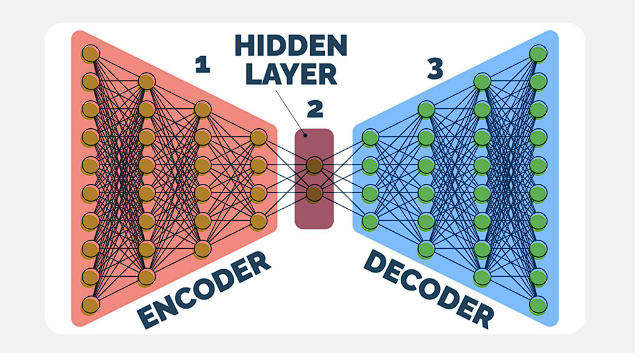

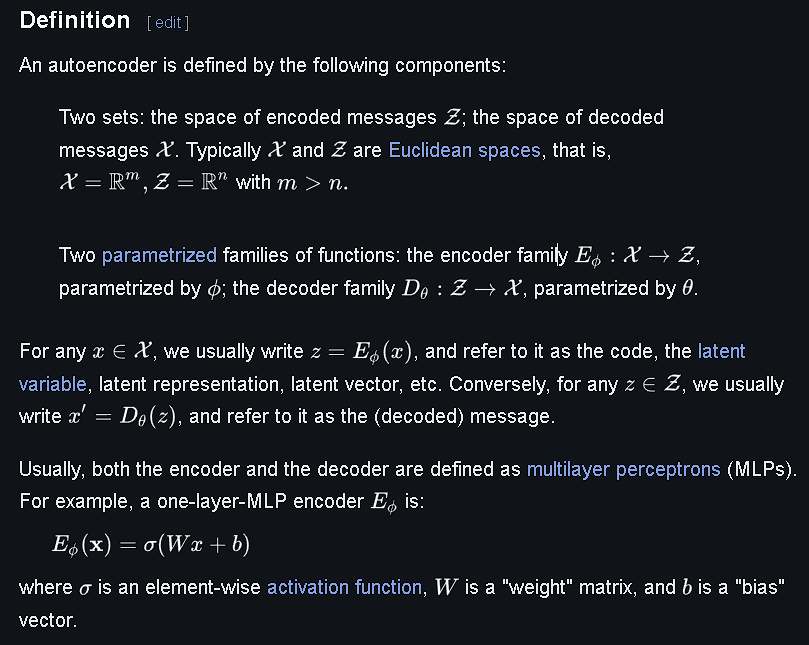

In [2]:
class LinearLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_features, out_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

        nn.init.xavier_uniform_(self.weight)
    
    def forward(self, x: torch.tensor):
        return x @ self.weight + self.bias

class Encoder(nn.Module):
    def __init__(self, input_message_dim: int, hidden_dim: int, encoded_message_dim: int):
        super().__init__()
        self.linear_1 = LinearLayer(input_message_dim, hidden_dim)
        self.linear_2 = LinearLayer(hidden_dim, encoded_message_dim)
    
    def forward(self, message: torch.tensor):
        encoded_message = self.linear_2(torch.sigmoid(self.linear_1(message)))
        return encoded_message

class Decoder(nn.Module):
    def __init__(self, encoded_msg_dim: int, hidden_dim: int, decoded_msg_dim: int):
        super().__init__()
        self.linear_1 = LinearLayer(encoded_msg_dim, hidden_dim)
        self.linear_2 = LinearLayer(hidden_dim, decoded_msg_dim)

    def forward(self, encoded_msg: torch.tensor):
        decoded_message = torch.sigmoid(self.linear_2(torch.sigmoid(self.linear_1(encoded_msg))))
        return decoded_message

class AutoEncoder(nn.Module):
    def __init__(self, input_message_dim: int,
                        enc_hidden_dim: int,
                        encoded_message_dim: int,
                        dec_hidden_dim: int):
        super().__init__()
        self.encoder = Encoder(input_message_dim = input_message_dim, hidden_dim = enc_hidden_dim, encoded_message_dim = encoded_message_dim)
        self.decoder = Decoder(encoded_msg_dim = encoded_message_dim, hidden_dim = dec_hidden_dim, decoded_msg_dim = input_message_dim)

    def forward(self, x: torch.tensor):
        self.latent_representation = self.encoder(x)
        return self.decoder(self.latent_representation)

## Training This AutoEncoder for MNIST Dataset

In [3]:
import numpy as np
import struct
from array import array
from os.path  import join
import torch

class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (torch.tensor(np.array(x_train)), torch.tensor(np.array(y_train))),(torch.tensor(np.array(x_test)), torch.tensor(np.array(y_test)))    

In [13]:
import matplotlib.pyplot as plt

input_path = './data'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

def show_images(images, title_texts, rows=1, cols=2, save_path=None):
    plt.figure(figsize=(cols * 4, rows * 4))
    index = 1

    for img, title in zip(images, title_texts):
        plt.subplot(rows, cols, index)
        plt.imshow(img, cmap='gray')
        plt.title(title, fontsize=12)
        plt.axis('off')
        index += 1

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)   # save high resolution

    plt.show()

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)

## Train the AutoEncoder

In [5]:
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()
x_train = x_train / 255.0
x_train = x_train.view(x_train.shape[0], -1)
auto_encoder = AutoEncoder(input_message_dim = x_train.shape[-1], enc_hidden_dim = 64, encoded_message_dim = 64, dec_hidden_dim = 64)
optimizer = torch.optim.Adam(params = auto_encoder.parameters(), lr = 0.001)

In [6]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

def train_auto_encoder(auto_encoder, x, optimizer, epochs, batch_size=32):
    auto_encoder.train()

    # Dataloader
    dataset = torch.utils.data.TensorDataset(x)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        epoch_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for batch in epoch_bar:
            batch = batch[0]
            output = auto_encoder(batch)
            loss = F.mse_loss(output, batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # live batch-wise loss inside progress bar
            epoch_bar.set_postfix(loss=loss.item())

        # print loss at interval
        if epoch % 5 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

In [7]:
train_auto_encoder(
    auto_encoder = auto_encoder,
    x = x_train,
    optimizer = optimizer,
    epochs = 120,
    batch_size = 64
)

Epoch 0, Loss: 0.065299


Epoch 5, Loss: 0.017465


Epoch 10, Loss: 0.011017


Epoch 15, Loss: 0.011884


Epoch 20, Loss: 0.007425


...

Epoch 95, Loss: 0.004265


Epoch 100, Loss: 0.004253


Epoch 105, Loss: 0.004015


Epoch 110, Loss: 0.004441


Epoch 115, Loss: 0.004057


In [32]:
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()
x_test = x_test / 255.0
x_test = x_test.view(x_test.shape[0], -1)

In [33]:
output = auto_encoder(x_test)

In [34]:
x_test.shape

torch.Size([10000, 784])

In [35]:
generated_images = output.view(output.shape[0], 28, 28)

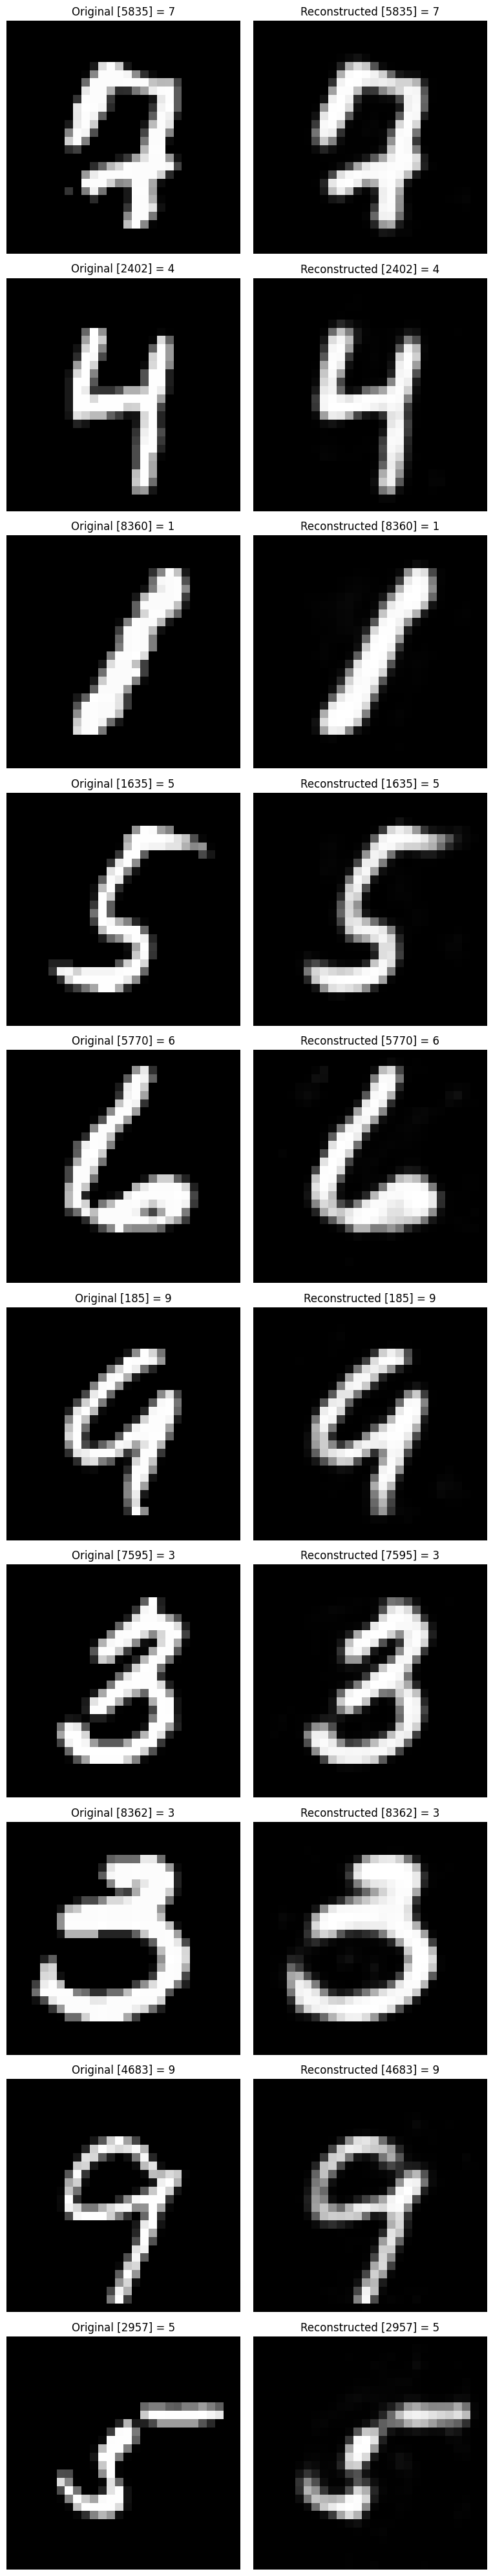

In [36]:
import random
images_2_show = []
titles_2_show = []

# reshape test images
x_test = x_test.view(-1, 28, 28)
generated_images = generated_images.view(-1, 28, 28).detach().numpy()   # ensure same shape

for i in range(10):  
    r = random.randint(0, len(x_test) - 1)

    # original
    images_2_show.append(x_test[r])
    titles_2_show.append(f"Original [{r}] = {y_test[r].item()}")

    # generated
    images_2_show.append(generated_images[r])
    titles_2_show.append(f"Reconstructed [{r}] = {y_test[r].item()}")
    
# show in rows of 2 (original + reconstructed)
show_images(images_2_show, titles_2_show, rows=10, cols=2, save_path = "mnist_reconstructions.png")

In [38]:
torch.save(auto_encoder.state_dict(), "autoencoder_weights.pth")

In [40]:
x_train.shape

torch.Size([60000, 28, 28])

In [42]:
auto_encoder = AutoEncoder(
    input_message_dim=x_train.shape[-1] * x_train.shape[-1],
    enc_hidden_dim=64,
    encoded_message_dim=64,
    dec_hidden_dim=64
)
auto_encoder.load_state_dict(torch.load("autoencoder_weights.pth", weights_only=True))
auto_encoder.eval()

AutoEncoder(
  (encoder): Encoder(
    (linear_1): LinearLayer()
    (linear_2): LinearLayer()
  )
  (decoder): Decoder(
    (linear_1): LinearLayer()
    (linear_2): LinearLayer()
  )
)

In [44]:
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()
x_test = x_test / 255.0
x_test = x_test.view(x_test.shape[0], -1)
auto_encoder(x_test)

tensor([[2.6119e-05, 2.7587e-05, 2.8736e-05,  ..., 2.7818e-05, 2.5272e-05,
         2.5140e-05],
        [4.5402e-05, 3.3996e-05, 3.9133e-05,  ..., 3.4977e-05, 4.3583e-05,
         3.8159e-05],
        [2.3931e-05, 2.6105e-05, 2.6995e-05,  ..., 2.5633e-05, 2.6142e-05,
         2.5123e-05],
        ...,
        [3.5558e-05, 3.4368e-05, 3.6668e-05,  ..., 3.7335e-05, 3.4889e-05,
         3.4784e-05],
        [2.8751e-05, 2.5276e-05, 3.2805e-05,  ..., 2.7738e-05, 2.6410e-05,
         2.4613e-05],
        [2.5189e-05, 2.5573e-05, 2.1913e-05,  ..., 2.3231e-05, 2.6249e-05,
         2.7100e-05]], grad_fn=<SigmoidBackward0>)